In [ ]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:

%load_ext autoreload
%autoreload 2

In [3]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()

number_of_files = 1
event_type = 'ttbar_pu200'
number_of_hf_repo_files= 1000
# Load particles
particles_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_particles/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        particles_list.append(pl.read_parquet(f))
particles = pl.concat(particles_list)

# Load calo_hits
calo_hits_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_calo_hits/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        calo_hits_list.append(pl.read_parquet(f))
calo_hits = pl.concat(calo_hits_list)

# Load tracks
tracks_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_tracks/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        tracks_list.append(pl.read_parquet(f))
tracks = pl.concat(tracks_list)

In [23]:
import torch
v = torch.__version__.split('+')[0]
c = torch.version.cuda.replace('.', '')
! pip install torch_scatter -f https://data.pyg.org/whl/torch-{v}+cu{c}.html

Defaulting to user installation because normal site-packages is not writeable
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 11.6 MB/s eta 0:00:00m eta 0:00:016m0:00:010m


In [5]:
from primary.clue import run_clue_hybrid
import torch
from primary.calibration import CALIBRATION
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv3
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles = set_target_particles_maskv3(particles, truth_eta_cut=3.0, truth_pt_cut=1.0, target_pt_cut=0.3)
event_id = 5
calo = calo_hits.filter(pl.col('event_id')<= event_id)
# create mappings between calo hits particle id and their target particle ids
from primary.preprocessing import backtrack_to_target
calo_deps_particles = (
    calo.lazy()
    .select('contrib_particle_ids', 'event_id')
    .explode('contrib_particle_ids')
    .explode('contrib_particle_ids')
    .rename({'contrib_particle_ids': 'particle_id'})
    .unique()
)
target_particles = (
    particles.lazy()
    .select('event_id', 'particle_id', 'is_target_particle', 'vertex_primary')
    .explode('particle_id','is_target_particle','vertex_primary')
    .filter(pl.col('is_target_particle') & (pl.col('event_id') <= event_id) & (pl.col('vertex_primary') == 1))
)

calo_deps_mappings = backtrack_to_target(particles, calo_deps_particles, target_particles)



Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 9397289 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 7 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


In [15]:
import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from primary.calibration import CALIBRATION
from primary.clustering import execute, metric_eval

# --------------------------------------------------------------------------------
# 1. SETUP & DEFINITIONS
# --------------------------------------------------------------------------------
event_id_until = 3
calo = calo_hits.filter(pl.col('event_id') <= event_id_until)

# Process Data: Explode -> Calibrate -> Group Back -> Pad
# This preserves the (Batch, Points) structure
data_processed = (
    calo.lazy()
    .select(['event_id', 'x', 'y', 'z', 'total_energy', 'detector'])
    .explode(['x', 'y', 'z', 'total_energy', 'detector'])
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('total_energy') * pl.col('calib_factor')).alias('energy'))
    .group_by('event_id', maintain_order=True)
    .agg([
        pl.col('x'), pl.col('y'), pl.col('z'), pl.col('energy'), pl.col('detector')
    ])
    .sort('event_id')
    .collect()
)

points_list = []
features_list = []

# Iterate and convert to Tensors
for row in data_processed.iter_rows(named=True):
    # Shape: (N_hits, 3)
    p = np.column_stack([row['x'], row['y'], row['z']])
    points_list.append(torch.tensor(p, dtype=torch.float32))
    
    # Shape: (N_hits,)
    f = np.array(row['energy'])
    features_list.append(torch.tensor(f, dtype=torch.float32))


# Pad Sequences to (Batch, Max_N, ...)
# Use a far-away value for padding coords so they don't cluster with real data
calo_points = pad_sequence(points_list, batch_first=True, padding_value=0) 
calo_features = pad_sequence(features_list, batch_first=True, padding_value=-1.0)

print(f"Data Loaded for events 0 to {event_id_until}.")
print(f"Points: {calo_points.shape}  (Batch, Hits, XYZ)")
print(f"Energy: {calo_features.shape}  (Batch, Hits)")

Data Loaded for events 0 to 3.
Points: torch.Size([4, 719876, 3])  (Batch, Hits, XYZ)
Energy: torch.Size([4, 719876])  (Batch, Hits)


In [11]:
# Calculate noise accumulated energy and signal clusters accumulated energy

from primary.calibration import CALIBRATION

# Explode calo to get per-hit data
exploded = (
    calo.lazy()
    .select('total_energy', 'detector', 'cluster_id')
    .explode('total_energy', 'detector', 'cluster_id')
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('total_energy') * pl.col('calib_factor')).alias('calibrated_energy'))
)

# Group by cluster_id and sum calibrated energies
energy_per_cluster = (
    exploded
    .group_by('cluster_id')
    .agg(pl.col('calibrated_energy').sum().alias('total_energy'))
    .collect()
)

# Noise accumulated energy (cluster_id == -1)
noise_energy = energy_per_cluster.filter(pl.col('cluster_id') == -1)['total_energy'].sum()

# Signal clusters accumulated energy (cluster_id != -1)
signal_clusters_energy = energy_per_cluster.filter(pl.col('cluster_id') != -1)

# Sum all signal clusters together
total_signal_energy = signal_clusters_energy['total_energy'].sum()

print(f"Noise accumulated energy: {noise_energy}")
print(f"Total signal clusters accumulated energy: {total_signal_energy}")

ColumnNotFoundError: unable to find column "cluster_id"; valid columns: ["event_id", "detector", "total_energy", "x", "y", "z", "contrib_particle_ids", "contrib_energies", "contrib_times"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
DF ["event_id", "detector", "total_energy", "x", ...]; PROJECT */9 COLUMNS

In [21]:
(calo.lazy().select('contrib_particle_ids', 'contrib_energies', 'event_id', 'cluster_id', 'detector')
 .explode('contrib_particle_ids', 'contrib_energies', 'cluster_id', 'detector')
 .explode('contrib_particle_ids', 'contrib_energies')
 .rename({'contrib_particle_ids':'particle_id', 'contrib_energies':'energy_contribution'})
 # Calibrate energy contributions
.join(CALIBRATION.lazy(), on='detector')
.with_columns((pl.col('energy_contribution') * pl.col('calib_factor')).alias('energy_contribution'))
 .join(
     particles.lazy()
     .filter(pl.col('event_id')==1)
     .select('event_id', 'particle_id','vertex_primary')
     .explode('particle_id','vertex_primary'), on=['event_id','particle_id'], how='inner'

 )
 #.filter(pl.col('vertex_primary')==1)
 .with_columns(pl.when(pl.col('vertex_primary') == 1).then(1).otherwise(0).alias('hard_scatter'))
 # two classes: cluster_id == -1 (noise), cluster_id != -1 (signal)
 .with_columns(pl.when(pl.col('cluster_id') == -1).then(0).otherwise(1).alias('is_signal'))
 .group_by('is_signal', 'event_id', 'hard_scatter')
 .agg(pl.col('energy_contribution').sum().alias('primary_energy_contribution'))
 ).collect()

ColumnNotFoundError: unable to find column "cluster_id"; valid columns: ["event_id", "detector", "total_energy", "x", "y", "z", "contrib_particle_ids", "contrib_energies", "contrib_times"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
DF ["event_id", "detector", "total_energy", "x", ...]; PROJECT */9 COLUMNS

In [ ]:
from primary.optimizer_clue import optimizer
optimizer(calo_hits=calo_hits, metric_eval=metric_eval, execute=execute, n_trials=1)

[I 2026-02-05 17:32:12,959] A new study created in memory with name: no-name-ede512c1-c75c-4f4a-87a6-899bebfbd062


Starting Optuna Optimization with 600 trials...
Note: Ensure 'execute' function accepts (calo, params_ecal, params_hcal) arguments.


[I 2026-02-05 17:32:14,766] Trial 0 finished with value: 0.5563563890629083 and parameters: {'ecal_rhoc': 0.11236203565420874, 'ecal_dc': 95.81071604484288, 'ecal_dm_ratio': 1.3659969709057025, 'hcal_rhoc': 0.35919509051822196, 'hcal_dc': 54.041677639819284, 'hcal_dm_ratio': 1.0779972601681014}. Best is trial 0 with value: 0.5563563890629083.
[I 2026-02-05 17:32:16,504] Trial 1 finished with value: 0.5280928294551815 and parameters: {'ecal_rhoc': 0.017425083650459836, 'ecal_dc': 88.62497239086949, 'ecal_dm_ratio': 1.3005575058716043, 'hcal_rhoc': 0.4248435466776273, 'hcal_dc': 41.85260448662222, 'hcal_dm_ratio': 1.484954926080997}. Best is trial 1 with value: 0.5280928294551815.
[I 2026-02-05 17:32:18,161] Trial 2 finished with value: 0.0481339869762689 and parameters: {'ecal_rhoc': 0.2497327922401265, 'ecal_dc': 33.04882440765347, 'ecal_dm_ratio': 1.0909124836035504, 'hcal_rhoc': 0.11004270591206029, 'hcal_dc': 67.38180186635839, 'hcal_dm_ratio': 1.262378215816119}. Best is trial 2 wi


--- Optimization Finished ---
Best Objective Value: 0.0044
Best Parameters:
  ecal_rhoc: 0.020417658226939882
  ecal_dc: 37.40710658685213
  ecal_dm_ratio: 1.0421539644618782
  hcal_rhoc: 0.01080674040319589
  hcal_dc: 124.4628976214855
  hcal_dm_ratio: 1.380373442733437

--- Running Final Execution with Best Parameters ---

Final Result:
Total Clusters: 9709
Ratio: 0.0180


(shape: (1, 13)
 ┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
 │ event_id ┆ detector  ┆ total_ene ┆ x         ┆ … ┆ cluster_c ┆ cluster_c ┆ cluster_c ┆ cluster_i │
 │ ---      ┆ ---       ┆ rgy       ┆ ---       ┆   ┆ x         ┆ y         ┆ z         ┆ d         │
 │ u32      ┆ list[u8]  ┆ ---       ┆ list[f32] ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
 │          ┆           ┆ list[f32] ┆           ┆   ┆ list[f32] ┆ list[f32] ┆ list[f32] ┆ list[i32] │
 ╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
 │ 1        ┆ [11, 11,  ┆ [0.000176 ┆ [-81.5999 ┆ … ┆ [-84.7005 ┆ [1013.477 ┆ [3344.938 ┆ [4910,    │
 │          ┆ … 10]     ┆ ,         ┆ 98, -306. ┆   ┆ 31, -337. ┆ 051, -376 ┆ 721, 3263 ┆ 4858, …   │
 │          ┆           ┆ 0.000072, ┆ 947235, … ┆   ┆ 919647, … ┆ .069916,  ┆ .381348,  ┆ 489]      │
 │          ┆           ┆ …         ┆ 28…       ┆   ┆ 26…       ┆ 

In [59]:
# Evaluate with the provided best parameters
event_id = 0
params_ecal = {
    "rhoc": 0.020417658226939882,
    "dc": 37.40710658685213,
    "dm": 37.40710658685213 * 1.0421539644618782,
    "max_neighbors": 300,
}

params_hcal = {
    "rhoc": 0.01080674040319589,
    "dc": 124.4628976214855,
    "dm": 124.4628976214855 * 1.380373442733437,
    "max_neighbors": 300,
}

calo, total_clusters = execute(calo, params_ecal, params_hcal, calo_points, calo_features)
ratio = metric_eval(calo, event_id=event_id, particles=particles, calo_deps_mappings=calo_deps_mappings)

print(f"Total Clusters: {total_clusters}")
print(f"Ratio (Noise/Signal): {ratio:.4f}")

"""
--- Optimization Finished ---
Best Objective Value: 0.0044
Best Parameters:
  ecal_rhoc: 0.020417658226939882
  ecal_dc: 37.40710658685213
  ecal_dm_ratio: 1.0421539644618782
  hcal_rhoc: 0.01080674040319589
  hcal_dc: 124.4628976214855
  hcal_dm_ratio: 1.380373442733437

--- Running Final Execution with Best Parameters ---

Final Result:
Total Clusters: 9709
Ratio: 0.0180
"""

IndexError: too many indices for tensor of dimension 2

In [16]:
from primary.clue import run_clue_hybrid
run_clue_hybrid(calo_points, calo_features, dc=45.9,dm=70.1,rhoc=0.17)

OutOfMemoryError: CUDA out of memory. Tried to allocate 10.95 GiB. GPU 0 has a total capacity of 47.37 GiB of which 9.04 GiB is free. Including non-PyTorch memory, this process has 38.32 GiB memory in use. Of the allocated memory 29.32 GiB is allocated by PyTorch, and 8.51 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [14]:

# 2. Force garbage collection
import gc


gc.collect()

# 3. Clear PyTorch CUDA cache
torch.cuda.empty_cache()

print("GPU Memory Released")

GPU Memory Released


In [21]:
from primary.interactive_plot import  plot_calo_clusters_interactive
plot_calo_clusters_interactive(calo, particles=particles.filter(pl.col("event_id") == 1), event_idx=1)
#Best ECAL: {'dc': 45.97769115408347, 'dm': 70.16613717473524, 'rhoc': 0.17722605917818973, 'max_neighbors': 300}
#Best HCAL: {'dc': 105.29947637865176, 'dm': 207.87708279592312, 'rhoc': 0.41209239491050614, 'max_neighbors': 300}

FigureWidget({
    'data': [{'customdata': array([[268, 1.0161891704683512, 0.7930212406248949,
                                    '<b>π-</b> (PDG:-211) ID:173910: <b>0.3814 GeV</b><br><b>e-</b> (PDG:11) ID:173911: <b>0.2394 GeV</b><br><b>π-</b> (PDG:-211) ID:89260: <b>0.164 GeV</b><br><b>e-</b> (PDG:11) ID:173913: <b>0.0988 GeV</b><br><b>e+</b> (PDG:-11) ID:173912: <b>0.0709 GeV</b>'],
                                   [5514, 0.1614174978385563, 0.822282958613623,
                                    '<b>K-</b> (PDG:-321) ID:622: <b>0.1327 GeV</b><br><b>π-</b> (PDG:-211) ID:52223: <b>0.0287 GeV</b>'],
                                   [6565, 0.0320455295877764, 1.0,
                                    '<b>n</b> (PDG:2112) ID:602: <b>0.032 GeV</b>'],
                                   ...,
                                   [2087, 0.7683626758080209, 1.0,
                                    '<b>e-</b> (PDG:11) ID:174320: <b>0.2404 GeV</b><br><b>e+</b> (PDG:-11) ID:174321: <b>0.2295 G

Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


In [22]:
calo_deps_mappings

event_id,src_particle_id,target_particle_id
u32,i64,i64
1,142160,null
1,94438,null
1,104262,null
1,13751,null
1,150166,null
…,…,…
1,173821,264
1,171069,465
1,174315,353


In [ ]:
# --------------------------------------------------------------------------------
# 2. OPTIMIZATION LOOP
# --------------------------------------------------------------------------------

print("\n--- 2. Starting Random Search ---")
print(f"{'Iter':<5} | {'ECAL rhoc':<10} {'HCAL rhoc':<10} | {'Clusters':<10} | {'Ratio':<10} | {'Status'}")

best_score = float('inf')
best_ecal_params = None
best_hcal_params = None

# Optimization Configuration
n_trials = 50

for i in range(n_trials):
    # 1. Sample Parameters
    # ECAL: Needs low rhoc (small cells), small dc
    current_ecal = params_ecal.copy()
    current_ecal['rhoc'] = np.random.uniform(0.05, 0.25)
    current_ecal['dm'] = current_ecal['dc'] * np.random.uniform(1.2, 2.0)
    
    # HCAL: Needs higher rhoc (pileup accumulation), large dc
    current_hcal = params_hcal.copy()
    current_hcal['rhoc'] = np.random.uniform(0.15, 0.55)
    current_hcal['dm'] = current_hcal['dc'] * np.random.uniform(1.2, 2.0)
    
    # 2. Run CLUE (Fast Wrapper)
    # We use a simplified runner that returns just the labels to save time
    global_cluster_ids = np.full(len(calo_points), -1, dtype=np.int32)
    c_offset = 0
    
    # Run ECAL
    mask_e = torch.isin(detector_ids_tensor, torch.tensor(ecal_ids, device=calo_points.device))
    _, lbls_e, n_e = run_clue_subset(calo_points, calo_features, mask_e, current_ecal, c_offset)
    
    if len(lbls_e) > 0:
        # Map subset indices back to global is tricky without the subset_idx return
        # So we re-run the mask logic briefly:
        idx_e = torch.where(mask_e)[0].cpu().numpy()
        global_cluster_ids[idx_e] = lbls_e
        c_offset += n_e
        
    # Run HCAL
    mask_h = torch.isin(detector_ids_tensor, torch.tensor(hcal_ids, device=calo_points.device))
    _, lbls_h, n_h = run_clue_subset(calo_points, calo_features, mask_h, current_hcal, c_offset)
    
    if len(lbls_h) > 0:
        idx_h = torch.where(mask_h)[0].cpu().numpy()
        global_cluster_ids[idx_h] = lbls_h
        c_offset += n_h
        
    total_clusters = c_offset
    
    # 3. Evaluate Metric (Fast Numpy Way)
    # Ratio = (Hard Scatter Energy in Noise) / (Hard Scatter Energy in Signal)
    # Signal is where cluster_id != -1
    noise_mask = (global_cluster_ids == -1)
    
    hs_lost_energy = np.sum(hs_energy_map[noise_mask])
    hs_found_energy = total_hs_energy - hs_lost_energy
    
    if hs_found_energy == 0:
        ratio = 1.0
    else:
        ratio = hs_lost_energy / hs_found_energy
        
    # 4. Objective Function
    # We want Ratio < 0.01 AND Clusters < 7000.
    # We penalize heavily if clusters > 7000
    penalty = 0
    if total_clusters > 7000:
        penalty = (total_clusters - 7000) * 0.0001 # Soft penalty
    
    # Primary goal is Ratio, Secondary is keeping clusters low
    score = ratio + penalty
    
    is_best = score < best_score
    status = "*" if is_best else ""
    
    print(f"{i:<5} | {current_ecal['rhoc']:.4f}     {current_hcal['rhoc']:.4f}     | {total_clusters:<10} | {ratio:.4f}     | {status}")
    
    if is_best:
        best_score = score
        best_ecal_params = current_ecal
        best_hcal_params = current_hcal

# --------------------------------------------------------------------------------
# 3. APPLY BEST PARAMS & EXECUTE
# --------------------------------------------------------------------------------
print("\n--- 3. Running Final Execution with Best Parameters ---")
print(f"Best ECAL: {best_ecal_params}")
print(f"Best HCAL: {best_hcal_params}")

# UPDATE THE GLOBAL PARAMS so your execute() function uses them
params_ecal = best_ecal_params
params_hcal = best_hcal_params

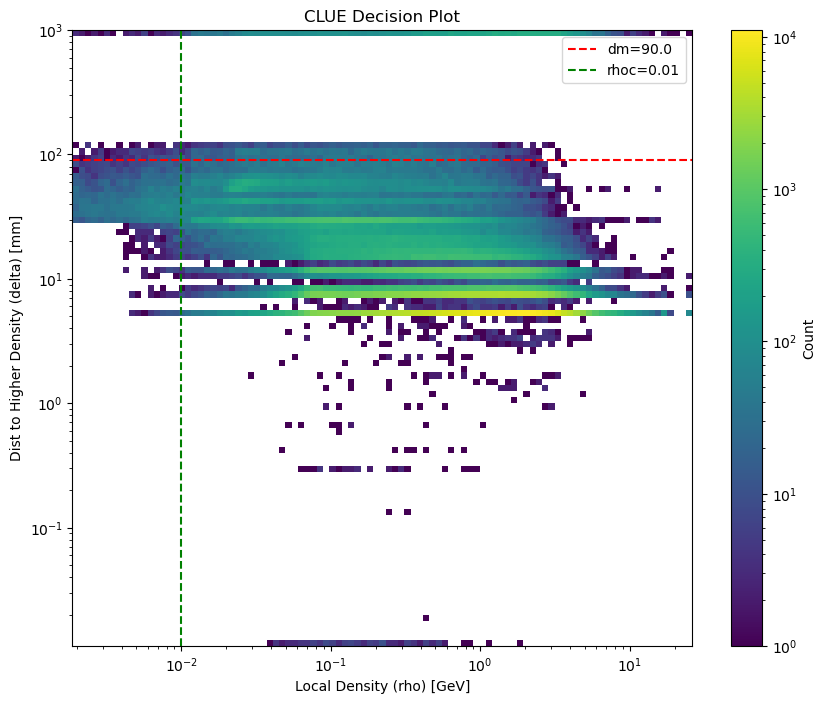

In [25]:
# Visualise Decision Plot (2D Histogram)
plt.figure(figsize=(10, 8))

# Handle infinities in delta for plotting by replacing with a large value
delta_np_plot = np.where(np.isfinite(delta_np), delta_np, 1e3)

# Define bins
x_min = max(rho_np.min(), 1e-5)
x_max = rho_np.max()
y_min = max(delta_np_plot.min(), 1e-2)
y_max = 1e3  # Extend to include high delta values

xbins = np.logspace(np.log10(x_min), np.log10(x_max), 100)
ybins = np.logspace(np.log10(y_min), np.log10(y_max), 100)

plt.hist2d(rho_np, delta_np_plot, bins=[xbins, ybins], norm=plt.matplotlib.colors.LogNorm(), cmap='viridis')
plt.colorbar(label='Count')
plt.xlabel("Local Density (rho) [GeV]")
plt.ylabel("Dist to Higher Density (delta) [mm]")
plt.title("CLUE Decision Plot")
plt.xscale('log')
plt.yscale('log')

# Draw your proposed cuts
dm_cut = 90.0
rhoc_cut = 0.01  # Example value, adjust based on the density of noise blob (bottom left)
plt.axhline(y=dm_cut, color='r', linestyle='--', label=f'dm={dm_cut}')
plt.axvline(x=rhoc_cut, color='g', linestyle='--', label=f'rhoc={rhoc_cut}')
plt.legend()
plt.show()

In [5]:
from primary.clue import run_clue_pytorch
from primary.calibration import CALIBRATION

calo = calo_hits.filter(pl.col('event_id') == 1)
energy = (
    calo.lazy().select(pl.col('total_energy'), pl.col('detector'))
    .explode('total_energy', 'detector')
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('total_energy') * pl.col('calib_factor')).alias('total_energy'))
    .select('total_energy')
).collect().to_numpy().reshape(-1)

In [6]:
energy.shape

(622618,)

In [38]:
delta_np

array([inf, inf, inf, ..., inf, inf, inf], shape=(622618,), dtype=float32)

In [34]:
calo_points.shape, calo_features.shape

(torch.Size([622618, 3]), torch.Size([622618, 1]))

In [26]:
delta

tensor([0.4630, 0.5809, 2.3646,  ..., 0.0000, 0.0000, 0.0000], device='cuda:0')

In [20]:
v = torch.__version__.split('+')[0]
c = torch.version.cuda# filepath: /storage/agrp/barakma/PileupODD/pileup_analysis.ipynb

c,v

('12.6', '2.6.0')

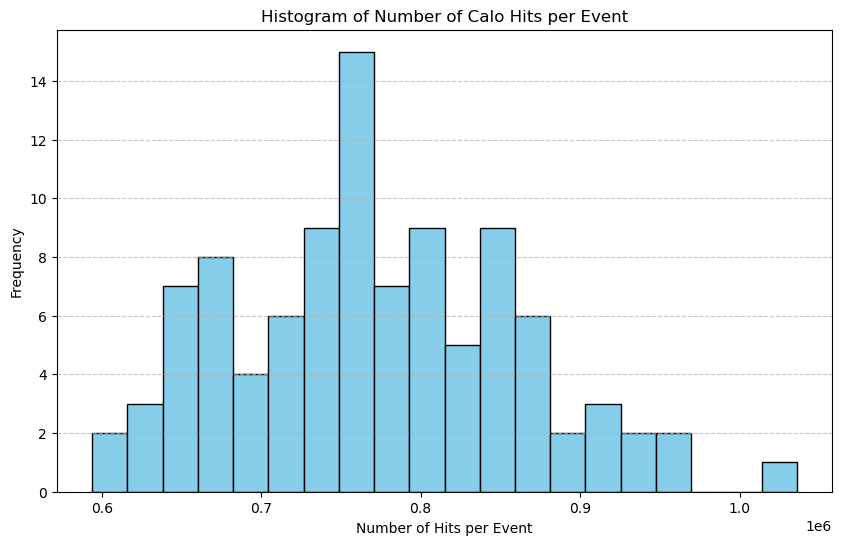

In [10]:
import matplotlib.pyplot as plt

# Compute the number of hits per event
num_hits_per_event = (
    calo_hits.select([
        "event_id",
        pl.col("detector").list.len().alias("n_hits")
    ])
    .group_by("event_id")
    .agg(pl.col("n_hits").sum())
    .get_column("n_hits")
    .to_numpy()
)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(num_hits_per_event, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Number of Hits per Event')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Calo Hits per Event')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [64]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv3
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles_copy = particles.clone()

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 9397289 depositors.


In [65]:
particles = set_target_particles_maskv3(particles, truth_eta_cut=3.0, truth_pt_cut=1.0, target_pt_cut=0.3)

Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 7 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


In [24]:
import matplotlib.pyplot as plt
import polars as pl

# Calculate number of particles per vertex_primary
particles_per_vertex = (
    particles.lazy()
    .select('vertex_primary', 'event_id')
    .explode('vertex_primary')
    .group_by('vertex_primary', 'event_id')
    .len()
    .collect()
)

# Compute averages for categories
avg_particles_gt1 = particles_per_vertex.filter(pl.col('vertex_primary') > 1)['len'].mean()
avg_particles_eq1 = particles_per_vertex.filter(pl.col('vertex_primary') == 1)['len'].mean()

# Create a DataFrame for display
averages = pl.DataFrame({
    'Category': ['vertex_primary > 1', 'vertex_primary == 1'],
    'Average Particles': [avg_particles_gt1, avg_particles_eq1]
})

print(averages)

shape: (2, 2)
┌─────────────────────┬───────────────────┐
│ Category            ┆ Average Particles │
│ ---                 ┆ ---               │
│ str                 ┆ f64               │
╞═════════════════════╪═══════════════════╡
│ vertex_primary > 1  ┆ 854.927233        │
│ vertex_primary == 1 ┆ 5231.93           │
└─────────────────────┴───────────────────┘


In [33]:
(particles.lazy()
    .select('vertex_primary', 'event_id', 'is_parent_missing')
    .explode('vertex_primary', 'is_parent_missing')
    .filter(pl.col('is_parent_missing') == True)
    ).collect()

vertex_primary,event_id,is_parent_missing
u16,u32,bool
1,26,true
1,26,true
1,26,true
1,26,true
1,26,true
…,…,…
211,90,true
211,90,true
211,90,true


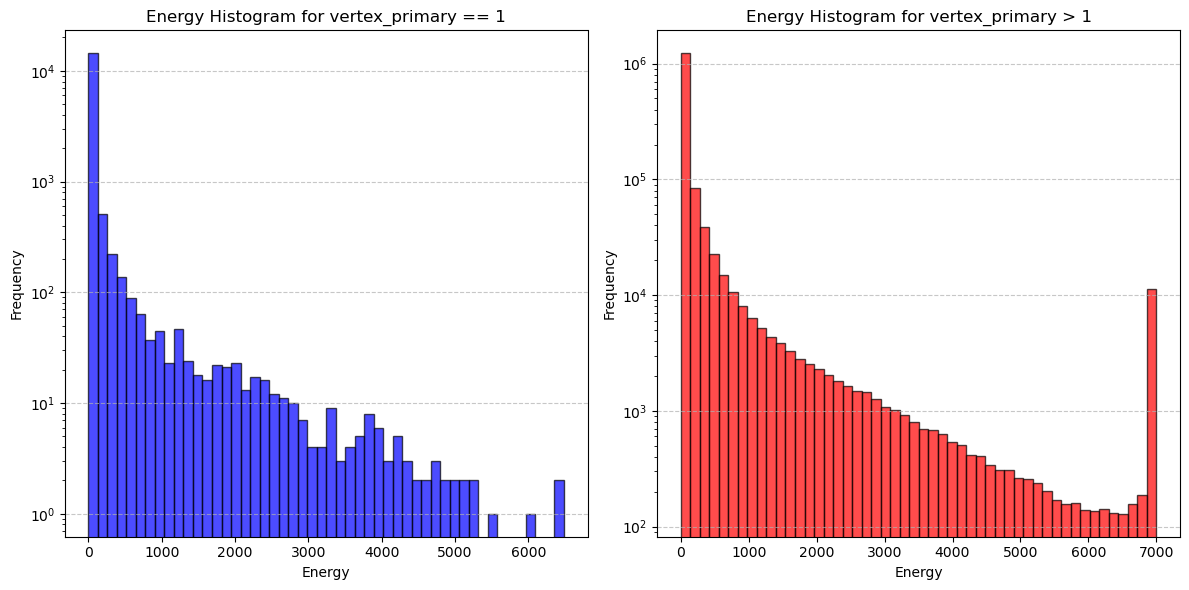

In [36]:
import matplotlib.pyplot as plt
import polars as pl

# Explode particles data to get per-particle energy and vertex_primary
exploded = (particles.lazy()
    .select('vertex_primary',  'is_parent_missing', 'energy')
    .explode('vertex_primary', 'is_parent_missing', 'energy')
    .filter(pl.col('is_parent_missing') == True)
    ).collect()
# Filter energies for vertex_primary == 1
energy_eq1 = exploded.filter(pl.col('vertex_primary') == 1)['energy']

# Filter energies for vertex_primary > 1
energy_gt1 = exploded.filter(pl.col('vertex_primary') > 1)['energy']

# Plot histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(energy_eq1, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Energy Histogram for vertex_primary == 1')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.hist(energy_gt1, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Energy Histogram for vertex_primary > 1')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')

plt.tight_layout()
plt.show()

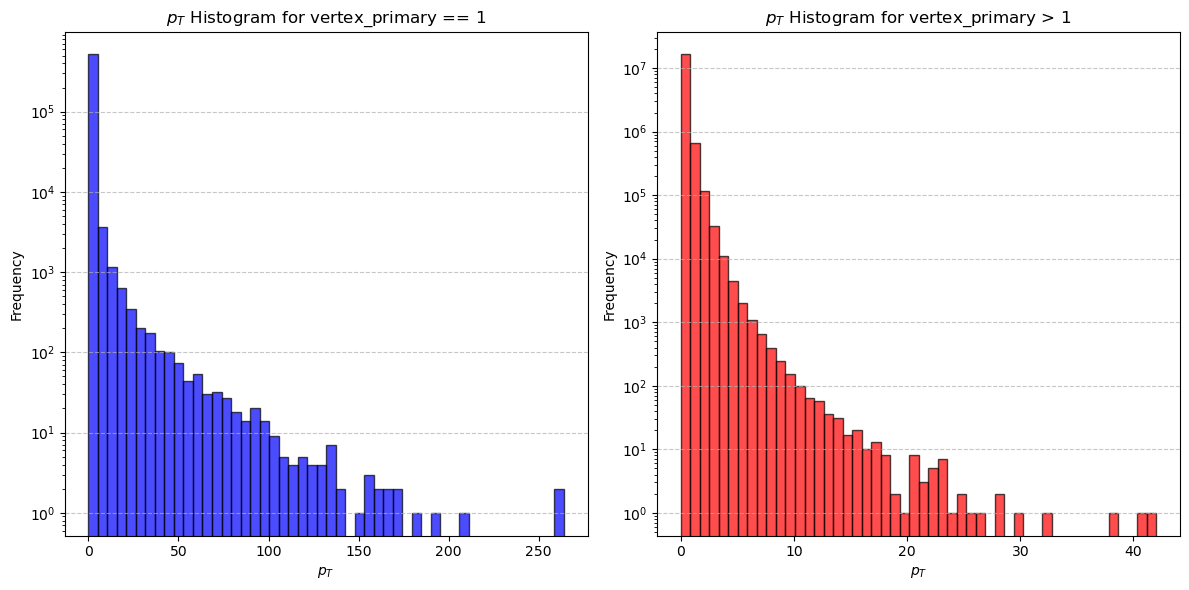

In [30]:
import matplotlib.pyplot as plt
import polars as pl

# Explode particles data to get per-particle energy and vertex_primary
exploded = (
    particles.lazy()
    .select('vertex_primary', 'pt')
    .explode('vertex_primary', 'pt')
    .collect()
)

# Filter energies for vertex_primary == 1
energy_eq1 = exploded.filter(pl.col('vertex_primary') == 1)['pt']

# Filter energies for vertex_primary > 1
energy_gt1 = exploded.filter(pl.col('vertex_primary') > 1)['pt']

# Plot histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(energy_eq1, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('$p_T$ Histogram for vertex_primary == 1')
plt.xlabel('$p_T$')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.hist(energy_gt1, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('$p_T$ Histogram for vertex_primary > 1')
plt.xlabel('$p_T$')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')

plt.tight_layout()
plt.show()

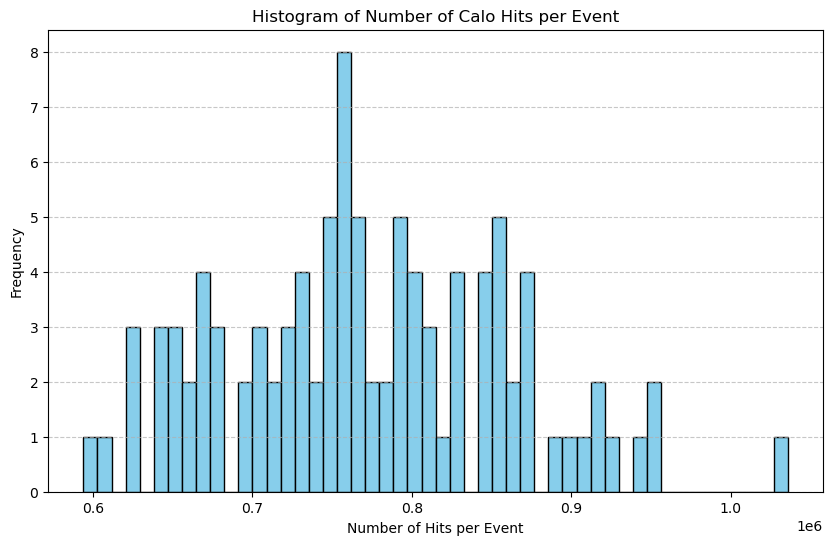

In [6]:
import matplotlib.pyplot as plt

# Since the schema uses list columns for each event, the number of hits is the length of these lists.
# We group by event_id and sum the lengths in case an event is split across multiple rows.
num_hits_per_event = (
    calo_hits.select([
        "event_id",
        pl.col("detector").list.len().alias("n_hits")
    ])
    .group_by("event_id")
    .agg(pl.col("n_hits").sum())
    .get_column("n_hits")
    .to_numpy()
)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(num_hits_per_event, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Number of Hits per Event')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Calo Hits per Event')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from primary.calibration import CALIBRATION
()

In [12]:
# bad config
from primary.interactive_plot import target_vs_truth_particles
target_vs_truth_particles(particles)

Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 11 iterations.
Step 4: Final validation...


    'data': [{'customdata': array([[  331.        ,  9261.1640625 ],
           …

In [9]:
from primary.preprocessing import add_ms_cluster_labels
calo = calo_hits.filter(pl.col("event_id") == 0)
calo = add_ms_cluster_labels(calo, bandwidth=120.0)

--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 1 events. Time: 0.02s
Workload optimized: 1 events merged into 1 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 179.65s


In [9]:
from primary.preprocessing import add_ms_cluster_labels_gpu
calo = calo_hits.filter(pl.col("event_id") == 0)
calo = add_ms_cluster_labels_gpu(calo, bandwidth=120.0)

--- Starting FAST GPU Clustering (Float32, MeanShift, bw=120.0) ---
Data prepared: 1 events. GPU Load Time: 0.04s


Processing Events:   0%|                                                                                                                 | 0/1 [01:37<?, ?it/s]


AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [8]:
import torch

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available")

GPU: NVIDIA RTX A5000


In [12]:
particles.select('vertex_primary')

vertex_primary
list[u16]
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"
…
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"


In [49]:
from primary.interactive_plot import  plot_calo_clusters_interactive
plot_calo_clusters_interactive(calo, particles=particles.filter(pl.col("event_id") == 0), event_idx=0)


No clusters found for event 0.


event_id,ht_target,ht_truth
u32,f32,f32
10,3771.317871,3915.379639
19,2959.985596,3048.139404
35,3465.338867,3584.286865
69,3455.357666,3595.883545
12,2864.208252,2972.331543
…,…,…
32,3615.420898,3717.498047
84,2428.414307,2522.760742
44,3639.218018,3829.91626


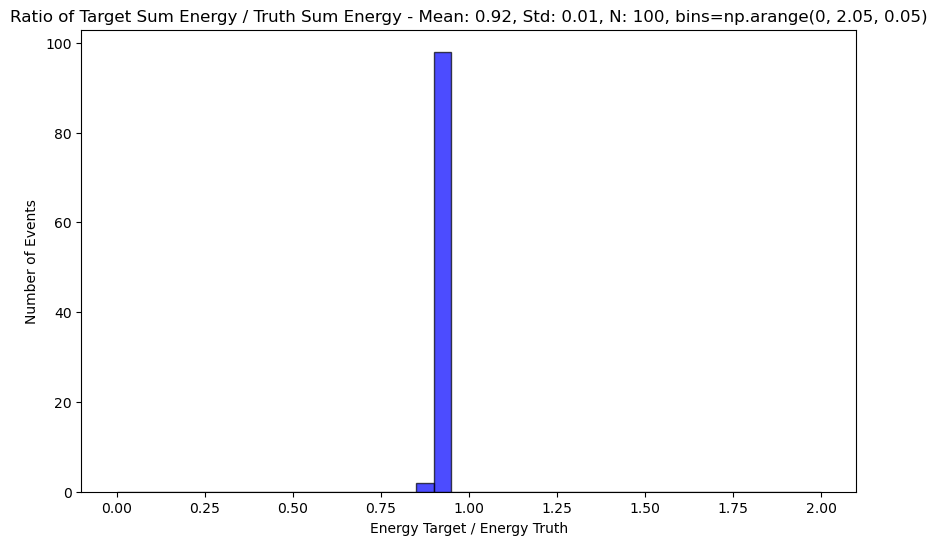

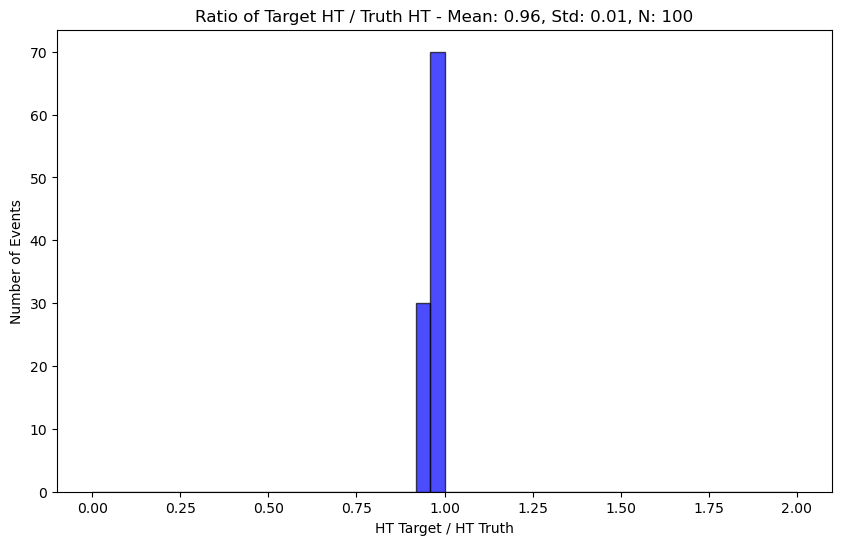

In [13]:
from primary.plot import histogram_ht_ratio,hist2d_ht_truth_vs_target, histogram_energy_ratio
histogram_energy_ratio(particles)
histogram_ht_ratio(particles)

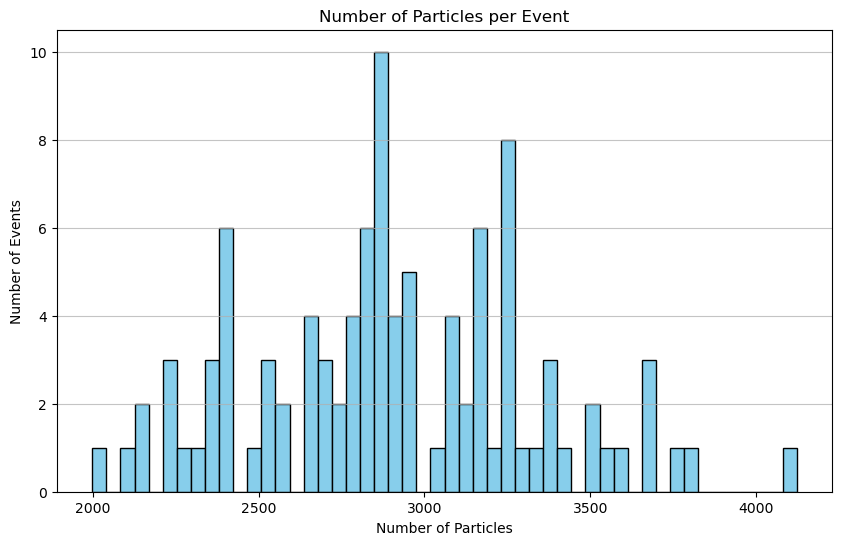

In [15]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = (
    particles.lazy()
    .select('event_id', 'particle_id', 'is_target_particle')
    .explode('particle_id', 'is_target_particle')
    .filter('is_target_particle')
    .group_by('event_id')
    .agg(pl.col('particle_id').count().alias('num_particles'))
    .collect()
)

plt.figure(figsize=(10, 6))
plt.hist(n_particles['num_particles'], bins=50, color='skyblue', edgecolor='black')
plt.title('Number of Particles per Event')
plt.xlabel('Number of Particles')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()